# RateWalk: forecasting Fed rate decisions with a Markov chain

*A research notebook. The goal here is not a polished result handed down from on
high, but the actual path: a simple idea, an honest out-of-sample test, a
surprise, a diagnosis, a fix, and a sober look at what does and does not work.*

**The question.** Can a memoryless Markov chain on the Fed's rate *moves*
(`-50/-25/0/+25/+50/+75` bps) predict the next decision out of sample? And if I
condition the chain on the inflation regime, does it get better? Everything
below is strictly no-look-ahead: every prediction at month *t* uses only data
that was public before *t*, and CPI is read at its real (ALFRED) release date so
revisions never leak.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":0.25,
                     "axes.spines.top":False, "axes.spines.right":False,
                     "font.size":10})
FIG = Path("../paper/figs"); FIG.mkdir(parents=True, exist_ok=True)
AU = "#c8932b"   # accent

from ratewalk import config as cfg
from ratewalk.data import load_macro
c = cfg.load()
md_us = load_macro(country="US", source="fred", start="1990-01-01", cpi_vintage=True)
print("data source:", md_us.source)
print("policy rate: %d obs, latest %.2f%%" % (len(md_us.policy_rate), md_us.policy_rate['rate'].iloc[-1]))
print("CPI YoY:     %d obs, latest %.2f%%" % (len(md_us.cpi_yoy), md_us.cpi_yoy['cpi_yoy'].iloc[-1]))
print("curve tenors:", [t for t in md_us.curve.columns if t!='date'])

data source: fred
policy rate: 13325 obs, latest 3.63%
CPI YoY:     424 obs, latest 4.26%
curve tenors: ['0.25', '1', '2', '3', '5', '7', '10', '20', '30']


## 1. The data, and why point-in-time matters

The policy rate and CPI move together with a lag. But there is a trap: CPI is
*revised*. If I train on the latest, revised CPI print, I am quietly using
information that did not exist at the time of the decision. ALFRED gives the
**initial release** value dated by its real publication date, so the model only
ever sees what was knowable then.

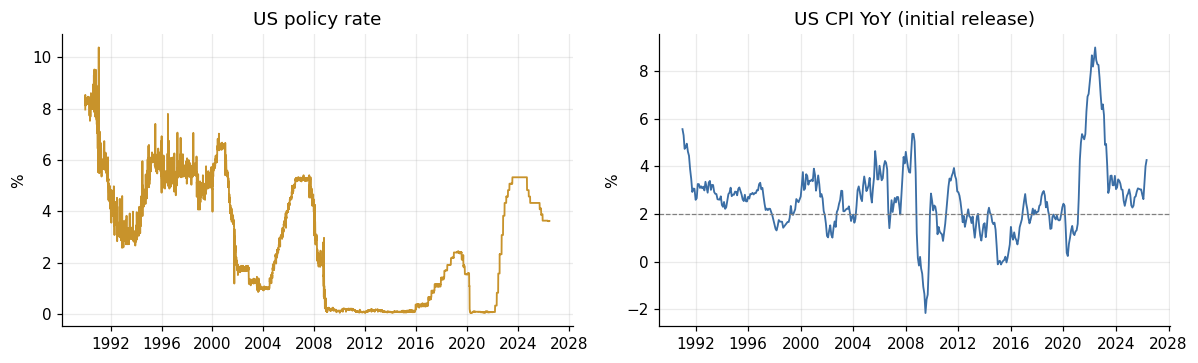

months where initial-release YoY differs from revised: 296 of 364 | max diff 0.35 pp


In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
p = md_us.policy_rate; q = md_us.cpi_yoy
ax[0].plot(pd.to_datetime(p['date']), p['rate'], color=AU, lw=1.2)
ax[0].set_title("US policy rate"); ax[0].set_ylabel("%")
ax[1].plot(pd.to_datetime(q['date']), q['cpi_yoy'], color="#3b6ea5", lw=1.2)
ax[1].axhline(2, color="grey", ls="--", lw=0.8); ax[1].set_title("US CPI YoY (initial release)"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.savefig(FIG/"data.png", bbox_inches="tight"); plt.show()

# how different is the initial release from the revised series?
md_rev = load_macro(country="US", source="fred", start="1995-01-01", cpi_vintage=False)
v = md_us.cpi_yoy.rename(columns={'cpi_yoy':'vintage'})
r = md_rev.cpi_yoy.rename(columns={'cpi_yoy':'revised'})
m = pd.merge(v[['date','vintage']], r[['date','revised']], on='date')
diff = (m['vintage']-m['revised']).abs()
print("months where initial-release YoY differs from revised:", int((diff>0.01).sum()), "of", len(m),
      "| max diff %.2f pp" % diff.max())

About four out of five months differ between the initial release and the later
revised number, by up to a few tenths of a point. That is exactly the leak the
ALFRED path closes, and it is enough to matter for a calibration test.

## 2. From rates to states

I discretize two things: the **rate move** at each month into the FOMC grid, and
**CPI YoY** into inflation regimes. A first-order Markov chain is then just the
matrix of transition probabilities between move-states.

rate-move states: ['-50bps', '-25bps', '+0bps', '+25bps', '+50bps', '+75bps']
CPI regimes:      ['<0', '0-2', '2-3', '3-5', '>5']


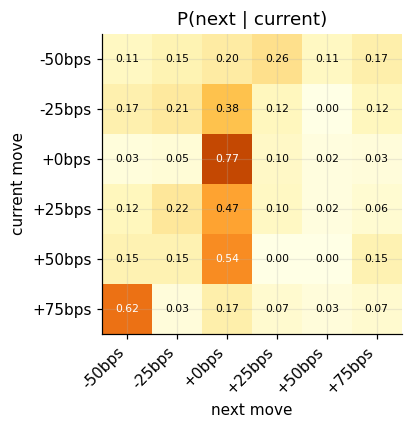

Rates are sticky: the +0bps row is dominated by staying at +0bps.


In [3]:
from ratewalk.walkforward import forecast as F
s = F.prepare_series(md_us, c)
print("rate-move states:", s.rate_space.labels)
print("CPI regimes:     ", s.cpi_space.labels)

# the unconditional transition matrix (full sample, just to look at it)
n = s.rate_space.n
P = np.zeros((n, n))
fr, to = s.state[:-1], s.state[1:]
for i in range(n):
    row = np.bincount(to[fr==i], minlength=n).astype(float)
    P[i] = row/row.sum() if row.sum() else row
fig, ax = plt.subplots(figsize=(4.6,4))
im = ax.imshow(P, cmap="YlOrBr", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(s.rate_space.labels, rotation=45, ha="right"); ax.set_yticklabels(s.rate_space.labels)
for i in range(n):
    for j in range(n):
        ax.text(j,i,f"{P[i,j]:.2f}",ha="center",va="center",fontsize=7,
                color="white" if P[i,j]>0.5 else "black")
ax.set_xlabel("next move"); ax.set_ylabel("current move"); ax.set_title("P(next | current)")
plt.tight_layout(); plt.savefig(FIG/"transition.png", bbox_inches="tight"); plt.show()
print("Rates are sticky: the +0bps row is dominated by staying at +0bps.")

## 3. The honest test: walk-forward, out of sample

Looking at an in-sample transition matrix proves nothing. The real test: at each
historical month, refit the chain on **past-only** data, predict the
distribution of the next move, and compare to what actually happened. I score
four things against each other:

- **climatology** - the unconditional frequency of moves (ignores everything),
- **unconditional chain** - `P(next | current move)`,
- **conditional (raw)** - `P(next | current move, CPI regime)`,
- and later, shrunk and empirical-Bayes versions.

Lower log-loss is better.

In [4]:
cmp = F.compare_models(s, min_train=120, n_dirichlet=1, shrink_tau=50.0,
                       rng=np.random.default_rng(0))
order = ["climatology","unconditional","conditional","conditional_shrunk","conditional_eb"]
tbl = pd.DataFrame({m: {"log_loss":cmp[m]["mean_log_loss"], "accuracy":cmp[m]["accuracy"]}
                    for m in order}).T
print(tbl.to_string())
print("\nOOS months:", cmp["summary"]["eval_points"])

                    log_loss  accuracy
climatology           1.1624    0.7170
unconditional         1.0705    0.6887
conditional           1.1356    0.6384
conditional_shrunk    1.0585    0.6855
conditional_eb        1.0654    0.6855

OOS months: 318


The first surprise. The plain chain **beats climatology** (1.07 vs 1.16) - it has
real predictive content. But conditioning on the CPI regime makes things
**worse** (1.14): the macro-aware model overfits. Why? Splitting the already
sparse non-hold transitions across five inflation regimes leaves each
regime-row estimated from a handful of observations. High variance.

## 4. Diagnosis and fix: shrinkage

If the problem is variance from sparse regime-rows, the fix is shrinkage: pull
each regime-specific row back toward the pooled (unconditional) row, hard when
the regime has little data and gently when it has a lot. That is a Dirichlet
prior centered on the pooled chain with strength `tau` pseudo-counts. `tau -> 0`
is the raw conditional model; `tau -> inf` is the unconditional model. Is there
an interior `tau` that beats both?

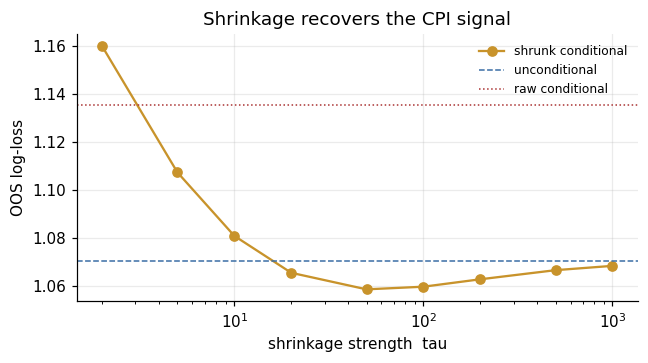

best shrunk log-loss: 1.0585  vs unconditional 1.0705


In [5]:
taus = [2,5,10,20,50,100,200,500,1000]
sweep = F.tau_sweep(s, taus, min_train=120, rng=np.random.default_rng(0))
xs = [r["tau"] for r in sweep]; ys = [r["log_loss"] for r in sweep]
unc = cmp["summary"]["logloss_unconditional"]; raw = cmp["summary"]["logloss_conditional_raw"]
fig, ax = plt.subplots(figsize=(6,3.4))
ax.plot(xs, ys, "-o", color=AU, label="shrunk conditional")
ax.axhline(unc, color="#3b6ea5", ls="--", lw=1, label="unconditional")
ax.axhline(raw, color="#a33", ls=":", lw=1, label="raw conditional")
ax.set_xscale("log"); ax.set_xlabel("shrinkage strength  tau"); ax.set_ylabel("OOS log-loss")
ax.set_title("Shrinkage recovers the CPI signal"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"tausweep.png", bbox_inches="tight"); plt.show()
print("best shrunk log-loss: %.4f  vs unconditional %.4f" % (min(ys), unc))

That is the flip. For a broad range of `tau` (roughly 20 to 500, a *plateau*,
not a knife-edge) the shrunk conditional model **beats the unconditional chain**.
The macro signal was real; it was just drowned in variance, and regularization
recovered it.

## 5. Robustness: does it replicate, and is `tau` cheating?

Two worries. First, did I just get lucky on US data? Second, did I tune `tau` to
the test set? I check both: re-run on the UK and Germany, and replace the fixed
`tau` with a **data-driven** one (empirical Bayes - estimate the Dirichlet
concentration from past-only data by maximizing its marginal likelihood).

         climatology  unconditional  conditional_raw  conditional_shrunk  conditional_eb
country                                                                                 
US            1.1624         1.0705           1.1356              1.0585          1.0654
GB            1.0104         0.8434           0.9041              0.8194          0.8425
DE            0.6153         0.5959           0.6616              0.5489          0.5628


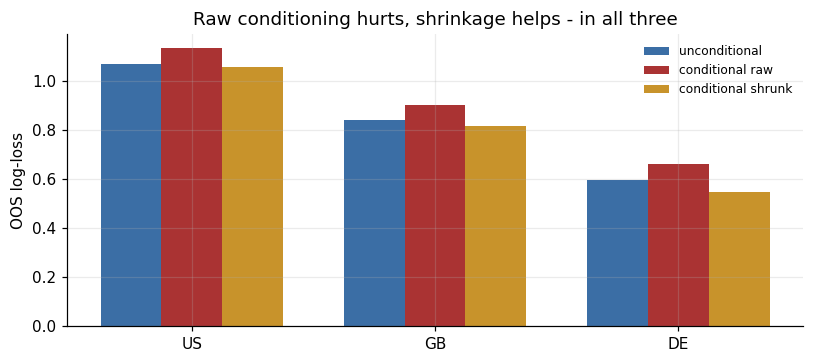

In [6]:
rows = []
for ctry in ["US","GB","DE"]:
    m_ = load_macro(country=ctry, source="fred", start="1990-01-01", cpi_vintage=True)
    s_ = F.prepare_series(m_, c)
    r_ = F.compare_models(s_, min_train=120, n_dirichlet=1, shrink_tau=50.0,
                          rng=np.random.default_rng(0))["summary"]
    rows.append({"country":ctry, "climatology":r_["logloss_climatology"],
                 "unconditional":r_["logloss_unconditional"],
                 "conditional_raw":r_["logloss_conditional_raw"],
                 "conditional_shrunk":r_["logloss_conditional_shrunk"],
                 "conditional_eb":r_["logloss_conditional_eb"]})
rep = pd.DataFrame(rows).set_index("country")
print(rep.round(4).to_string())

fig, ax = plt.subplots(figsize=(7.5,3.4))
xcols = ["unconditional","conditional_raw","conditional_shrunk"]
w=0.25; x=np.arange(len(rep))
cols = {"unconditional":"#3b6ea5","conditional_raw":"#a33","conditional_shrunk":AU}
for k,col in enumerate(xcols):
    ax.bar(x+(k-1)*w, rep[col], w, label=col.replace("_"," "), color=cols[col])
ax.set_xticks(x); ax.set_xticklabels(rep.index); ax.set_ylabel("OOS log-loss")
ax.set_title("Raw conditioning hurts, shrinkage helps - in all three"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"replication.png", bbox_inches="tight"); plt.show()

It replicates. In the US, UK and Germany the same pattern holds: raw conditioning
is worse than the unconditional chain, and the shrunk version is better. The
data-driven empirical-Bayes `tau` *also* beats the unconditional chain in all
three with no tuning at all - so the effect is not an artifact of my choosing
`tau`. (EB is a touch worse than a fixed moderate `tau` because it is
conservative when early data is thin, then adapts: by 2026 it settles near 130
for the US, 300 for the UK, and just 17 for Germany - German decisions are the
most inflation-regime-dependent.)

## 6. Does cadence matter? An honest negative

I expected that moving from monthly to the Fed's actual ~8-meetings-a-year
cadence would sharpen things by removing no-meeting months. It does not, really:
it helps the UK, is neutral for the US, and hurts Germany. The reason is
instructive - even at meeting frequency, 60 to 80% of decisions are *holds*,
because policy rates are intrinsically sticky. The dominance of "no change" is
not a sampling artifact, so changing the sampling does not fix it.

In [7]:
for freq in ["monthly","meeting"]:
    s_ = F.prepare_series(md_us, c, decision_freq=freq)
    hold = float(np.mean(s_.state==s_.rate_space.labels.index("+0bps")))
    sm = F.compare_models(s_, min_train=(120 if freq=="monthly" else 90), n_dirichlet=1,
                          shrink_tau=50.0, rng=np.random.default_rng(0))["summary"]
    print(f"{freq:8s}: {len(s_.state)} decisions, {hold*100:.0f}% holds | "
          f"uncond {sm['logloss_unconditional']:.4f} -> shrunk {sm['logloss_conditional_shrunk']:.4f}")

monthly : 438 decisions, 59% holds | uncond 1.0705 -> shrunk 1.0585
meeting : 290 decisions, 62% holds | uncond 0.9473 -> shrunk 0.9373


## 7. From a forecast to a strategy

A calibrated forecast is not yet money. The last honest step: turn the model's
expected move into a duration tilt (expect cuts -> go long duration; expect hikes
-> go short), and measure the realized return on the actual Treasury curve
against constant-duration benchmarks, out of sample.

strategy : {'n': 317, 'cum_return': 0.9432, 'ann_return': 0.0255, 'ann_vol': 0.0241, 'sharpe': 1.059, 'max_drawdown': -0.0942}
bench 2.0y: {'n': 317, 'cum_return': 0.9027, 'ann_return': 0.0245, 'ann_vol': 0.0176, 'sharpe': 1.391, 'max_drawdown': -0.0606}
bench 10.0y: {'n': 317, 'cum_return': 1.815, 'ann_return': 0.0421, 'ann_vol': 0.0753, 'sharpe': 0.559, 'max_drawdown': -0.2592}


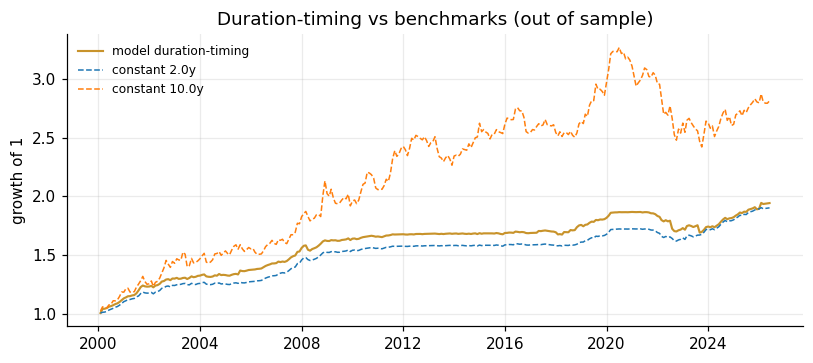

In [8]:
from ratewalk.walkforward.backtest import duration_backtest
bt = duration_backtest(s, md_us.curve, min_train=120)
print("strategy :", bt["strategy"])
for k,v in bt["benchmarks"].items(): print(f"bench {k}:", v)

ec = bt["equity_curves"]; d = pd.to_datetime(ec["dates"])
fig, ax = plt.subplots(figsize=(7.5,3.4))
ax.plot(d, ec["strategy"], color=AU, lw=1.4, label="model duration-timing")
for b in ["2.0y","10.0y"]:
    if b in ec: ax.plot(d, ec[b], lw=1, ls="--", label=f"constant {b}")
ax.set_ylabel("growth of 1"); ax.set_title("Duration-timing vs benchmarks (out of sample)")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(FIG/"backtest.png", bbox_inches="tight"); plt.show()

And here is the sober result: the timing strategy does **not** beat a plain
constant-2-year bond on a risk-adjusted basis (Sharpe ~1.06 vs ~1.39). It only
tilts long-duration about 7% of the time, and those tilts add volatility without
enough return. The 10-year buy-and-hold makes more total return but with a far
worse Sharpe and a brutal drawdown. The forecasting edge is real but it lives in
*probabilistic calibration*, not (yet) in a tradeable duration rule.

## 8. The live call

Finally, the forward-looking nowcast - the model's probability distribution over
the *next* decision, with a confidence interval from the Dirichlet posterior.

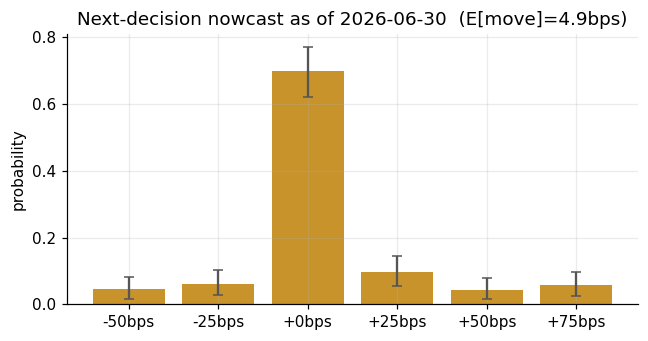

   -50bps  p=0.045   90% CI [0.017, 0.081]
   -25bps  p=0.062   90% CI [0.028, 0.103]
    +0bps  p=0.699   90% CI [0.621, 0.770]
   +25bps  p=0.095   90% CI [0.054, 0.146]
   +50bps  p=0.042   90% CI [0.015, 0.078]
   +75bps  p=0.057   90% CI [0.025, 0.097]


In [9]:
nc = F.nowcast(s, model="conditional_shrunk", shrink_tau=50.0)
labels = [d["move"] for d in nc["distribution"]]
probs = [d["prob"] for d in nc["distribution"]]
lo = [d["prob"]-d["ci"][0] for d in nc["distribution"]]
hi = [d["ci"][1]-d["prob"] for d in nc["distribution"]]
fig, ax = plt.subplots(figsize=(6,3.2))
ax.bar(labels, probs, color=AU, yerr=[lo,hi], capsize=3, ecolor="#555")
ax.set_ylabel("probability"); ax.set_title(f"Next-decision nowcast as of {nc['as_of']}  (E[move]={nc['expected_move_bps']}bps)")
plt.tight_layout(); plt.savefig(FIG/"nowcast.png", bbox_inches="tight"); plt.show()
for d in nc["distribution"]:
    print(f"  {d['move']:>7s}  p={d['prob']:.3f}   90% CI [{d['ci'][0]:.3f}, {d['ci'][1]:.3f}]")

## What I take away

A clean, honest arc:

1. A memoryless first-order Markov chain on Fed moves **beats a climatology
   baseline** out of sample.
2. Naively conditioning on the CPI regime **overfits and hurts** - a textbook
   bias-variance failure on sparse data.
3. **Shrinkage toward the pooled chain recovers a small but consistent macro
   edge**, and it **replicates across the US, UK and Germany**, survives a
   data-driven empirical-Bayes `tau`, and sits on a broad `tau` plateau rather
   than a tuned point.
4. **Cadence is not the lever** - hold-dominance is intrinsic to sticky policy.
5. The edge is in **calibration, not a tradeable duration strategy** - the
   backtest does not beat a constant-2-year bond risk-adjusted, and I say so.

Everything above is reproducible from a seed and runs under strict no-look-ahead
with point-in-time CPI. The honest negatives are part of the result, not
footnotes to it.

*Limitations and next steps: the meeting-cadence test used an approximate 8/year
grid, not the exact published FOMC calendar (the cleanest way to settle the
cadence question); the curve mapping is a per-tenor regression rather than a
full term-structure factor model; and the duration rule is deliberately simple.*